# Import modules

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime
import matplotlib.pyplot as plt

from tx_fast_hydrology.muskingum import Muskingum, ModelCollection
from tx_fast_hydrology.simulation import AsyncSimulation
from tx_fast_hydrology.io import ModelDecoder, ModelEncoder

# Read NHF flowpath data

In [2]:
# Read file
nhf_path = '/home/akagi/Documents/Data/txswift/nhf_1.1.3.gpkg'
df = gpd.read_file(nhf_path, layer='flowpaths')

# Process geopackage data
name = 'dfw'
start_date = pd.to_datetime(datetime.datetime.utcnow(), utc=True)
timedelta = pd.to_timedelta(1, unit='h')
reach_ids = df['fp_id'].astype(str).values
to_reach_ids = df['fp_to_id'].fillna(-1).astype(int).astype(str).values

# Prepare Muskingum model input data

In [3]:
# Establish drainage network topology
reach_index = pd.Series(df.index.values, index=reach_ids)
startnodes = reach_index.reindex(reach_ids, fill_value=-1).values
endnodes = reach_index.reindex(to_reach_ids, fill_value=-1).values
self_loops = []
for i in range(len(startnodes)):
    if endnodes[i] == -1:
        self_loops.append(i)
        endnodes[i] = startnodes[i]

# Specify parameters
K = 3600 * np.ones(df.shape[0], dtype=np.float64)                     # Travel times [s]
X = 0.29 * np.ones(df.shape[0], dtype=np.float64)                     # Attenuation parameter [-]
o_t = 0. * np.ones(df.shape[0], dtype=np.float64)                     # Initial outflow from each reach [m^3/s]
dx = (1000 * df['length_km']).values                                  # Reach lengths [m]

# Process flowpath geometries
linestring_geoms = df.geometry.apply(lambda x: x.geoms[0])            # Note: this flattens multilinestrings
paths = (linestring_geoms.apply(lambda x: [np.column_stack(x.xy)])
         .values.tolist())

# Apply initial flow to headwaters only
indegree = np.bincount(endnodes, minlength=len(startnodes))
o_t[indegree == 0] = 1.

# Package model instance data into dictionary

In [4]:
data = {
    'name' : name,
    'datetime' : start_date,
    'timedelta' : timedelta,
    'reach_ids' : reach_ids,
    'startnodes' : startnodes,
    'endnodes' : endnodes,
    'K' : K,
    'X' : X,
    'o_t' : o_t,
    'dx' : dx,
    'paths' : paths
}

# Instantiate Muskingum model

In [5]:
model = Muskingum(data)

# Plot domain

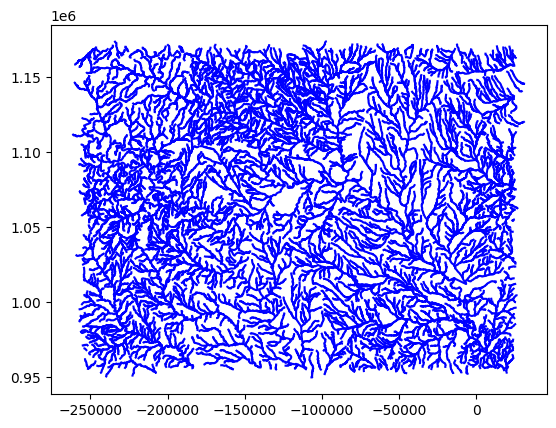

In [6]:
fig, ax = plt.subplots()
model.plot(ax=ax, c='b')

# Create precipitation forcing

In [7]:
n_steps = 24 * 7
date_range = pd.date_range(start=model.datetime + pd.to_timedelta('1h'), 
                           periods=n_steps, freq='1h', tz='utc')
# Note: precipitation forcing is zero for this test case
p_t = pd.DataFrame(0. * np.ones((n_steps, model.n)), index=date_range)
p_t.columns = model.reach_ids

# Run simulation over 7 days

In [8]:
model.init_states(o_t_next=o_t)

outputs = {}
outputs[model.datetime] = model.o_t_next

for state in model.simulate_iter(p_t):
    o_t_next = state.o_t_next
    outputs[state.datetime] = o_t_next
ref_outputs = pd.DataFrame.from_dict(outputs, orient='index')
ref_outputs.columns = model.reach_ids
ref_outputs.index = pd.to_datetime(ref_outputs.index, utc=True)

# Plot streamflow output

Text(0.5, 0, 'Time (h)')

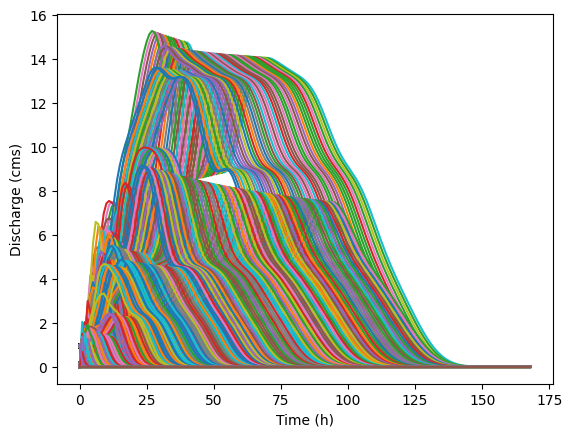

In [9]:
_ = plt.plot(ref_outputs.values)
plt.ylabel('Discharge (cms)')
plt.xlabel('Time (h)')

# Write discharge outputs to CSV file

In [10]:
ref_outputs.to_csv('../data/dfw_outputs_first_test.csv')

# Create model collection file

In [11]:
model_collection = ModelCollection([model], 'trinity')
model_collection.dump_model_collection('../data/trinity_muskingum.json')